In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path = '/content/drive/MyDrive/Glasser_HCP.zip'

In [ ]:
import os
print(os.path.exists(zip_path))  # should return True

True


In [ ]:
import zipfile
import os


extract_to = "output_folder"    # folder to save .netts files

# Create output folder if not exists
os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    for file in zip_ref.namelist():
        if file.endswith('.netts'):
            zip_ref.extract(file, extract_to)

print("Extraction complete!")

Extraction complete!


In [ ]:
import shutil
from google.colab import files

# Zip the folder
shutil.make_archive("plots1", 'zip', "plots1")

# Download it
files.download("plots1.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.stats import entropy

In [ ]:
import pandas as pd

cveda = pd.read_csv("cveda_z_smith10(in).csv")   # your file
print(cveda.columns)

Index(['sub_id', 'visual-medial_visual-occpol', 'visual-medial_visual-lateral',
       'visual-medial_default', 'visual-medial_cerebellum',
       'visual-medial_sensorimotor', 'visual-medial_auditory',
       'visual-medial_exec-control', 'visual-medial_fpn-percep',
       'visual-medial_fpn-lang', 'visual-occpol_visual-lateral',
       'visual-occpol_default', 'visual-occpol_cerebellum',
       'visual-occpol_sensorimotor', 'visual-occpol_auditory',
       'visual-occpol_exec-control', 'visual-occpol_fpn-percep',
       'visual-occpol_fpn-lang', 'visual-lateral_default',
       'visual-lateral_cerebellum', 'visual-lateral_sensorimotor',
       'visual-lateral_auditory', 'visual-lateral_exec-control',
       'visual-lateral_fpn-percep', 'visual-lateral_fpn-lang',
       'default_cerebellum', 'default_sensorimotor', 'default_auditory',
       'default_exec-control', 'default_fpn-percep', 'default_fpn-lang',
       'cerebellum_sensorimotor', 'cerebellum_auditory',
       'cerebellum_exe

**Permutation**

In [ ]:
import numpy as np
from scipy.signal import welch
from scipy.stats import entropy
def normalize(ts):
    return (ts - np.mean(ts)) / (np.std(ts) + 1e-8)

def spectral_entropy(ts):
    freqs, psd = welch(ts, nperseg=128)
    psd = psd / np.sum(psd)
    psd += 1e-12
    return entropy(psd)
# import numpy as np
# import itertools

# def normalize(ts):
#     return (ts - np.mean(ts)) / (np.std(ts) + 1e-8)

# def permutation_entropy(ts, order=5, delay=1):
#     ts = np.array(ts)

#     n = len(ts)
#     perms = list(itertools.permutations(range(order)))
#     c = {p: 0 for p in perms}

#     for i in range(n - delay * (order - 1)):
#         window = ts[i:(i + delay * order):delay]

#         # stable ranking (important)
#         ranks = tuple(np.argsort(np.argsort(window)))
#         c[ranks] += 1

#     counts = np.array(list(c.values()), dtype=float)
#     probs = counts / np.sum(counts)
#     probs += 1e-12

#     return -np.sum(probs * np.log(probs))

In [ ]:
import zipfile
import os

zip_path = "/content/netts_files.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [ ]:
import os
import numpy as np

netts_folder = "/content/Glasser_HCP"

data = []

for _, row in cveda.iterrows():

    subject_id = row["sub_id"]
    age = row["age"]

    file_path = os.path.join(netts_folder, subject_id + "_000.netts")

    if not os.path.exists(file_path):
        continue

    netts = np.loadtxt(file_path)

    for r in range(netts.shape[0]):   # 360 regions
        ts = normalize(netts[r, :])   # full time series
        ent = spectral_entropy(ts)

        data.append([subject_id, age, r, ent])

/tmp/ipykernel_1110/2923392493.py:8: UserWarning: nperseg=128 is greater than signal length max(len(x), len(y)) = 21, using nperseg = 21
  freqs, psd = welch(ts, nperseg=128)
/tmp/ipykernel_1110/2923392493.py:8: UserWarning: nperseg=128 is greater than signal length max(len(x), len(y)) = 53, using nperseg = 53
  freqs, psd = welch(ts, nperseg=128)
/tmp/ipykernel_1110/2923392493.py:8: UserWarning: nperseg=128 is greater than signal length max(len(x), len(y)) = 51, using nperseg = 51
  freqs, psd = welch(ts, nperseg=128)
/tmp/ipykernel_1110/2923392493.py:8: UserWarning: nperseg=128 is greater than signal length max(len(x), len(y)) = 43, using nperseg = 43
  freqs, psd = welch(ts, nperseg=128)
/tmp/ipykernel_1110/2923392493.py:8: UserWarning: nperseg=128 is greater than signal length max(len(x), len(y)) = 104, using nperseg = 104
  freqs, psd = welch(ts, nperseg=128)


In [ ]:
df = pd.DataFrame(data, columns=["subject", "age", "region", "entropy"])

In [ ]:
df['region'].unique()

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [ ]:
df

,subject,age,region,entropy
0,sub-000010155078,7.460643,0,3.185262
1,sub-000010155078,7.460643,1,3.619563
2,sub-000010155078,7.460643,2,3.678560
3,sub-000010155078,7.460643,3,3.431388
4,sub-000010155078,7.460643,4,3.463287
...,...,...,...,...
368635,sub-000099935945,17.108830,355,3.345363
368636,sub-000099935945,17.108830,356,3.764613
368637,sub-000099935945,17.108830,357,3.689226
368638,sub-000099935945,17.108830,358,3.778289


In [ ]:
output_folder = "plots/"
os.makedirs(output_folder, exist_ok=True)

regions = df["region"].unique()

for r in regions:
    sub_df = df[df["region"] == r]

    plt.figure()
    plt.scatter(sub_df["age"], sub_df["entropy"])

    plt.xlabel("Age")
    plt.ylabel("Entropy")
    plt.title(f"Region {r}: Age vs Entropy")

    plt.savefig(f"{output_folder}/region_{r}.png")
    plt.close()

In [ ]:
import os

input_folder = "plots"
output_folder = "plots1"

os.makedirs(output_folder, exist_ok=True)
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

regions = df["region"].unique()

for r in regions:
    sub_df = df[df["region"] == r]

    age = sub_df["age"].values
    entropy = sub_df["entropy"].values

    # regression
    slope, intercept, r_value, p_value, _ = linregress(age, entropy)

    # plot
    plt.figure()
    plt.scatter(age, entropy, alpha=0.5)

    # regression line
    x = np.linspace(min(age), max(age), 100)
    y = slope * x + intercept
    plt.plot(x, y)

    plt.xlabel("Age")
    plt.ylabel("Entropy")
    plt.title(f"Region {r} | r={r_value:.3f}, p={p_value:.3f}")

    # save in new folder
    plt.savefig(os.path.join(output_folder, f"region_{r}.png"))
    plt.close()

In [ ]:
from scipy.stats import pearsonr

results = []

for r in df["region"].unique():
    sub_df = df[df["region"] == r]

    corr,p = pearsonr(sub_df["age"], sub_df["entropy"])

    results.append((r, corr,p))


In [ ]:
results = sorted(results, key=lambda x: abs(x[1]), reverse=True)

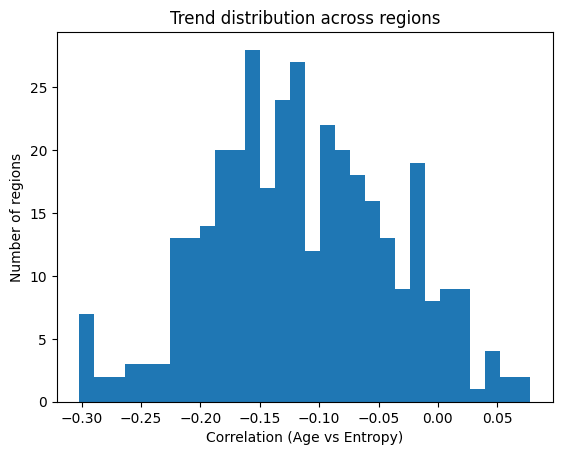

In [ ]:
corrs = [x[1] for x in results]

import matplotlib.pyplot as plt

plt.hist(corrs, bins=30)
plt.xlabel("Correlation (Age vs Entropy)")
plt.ylabel("Number of regions")
plt.title("Trend distribution across regions")
plt.show()

In [ ]:
positive = [r for r, c, p in results if c > 0.2]
negative = [r for r, c, p in results if c < -0.2]
neutral  = [r for r, c, p in results if abs(c) <= 0.2]

print("Positive:", len(positive))
print("Negative:", len(negative))
print("Neutral:", len(neutral))

Positive: 0
Negative: 46
Neutral: 314


In [ ]:
import re

text = """
#    N_vox  N_nonnull      frac  #     ROI  ROI_label
      1744       1744   1.00000  #       1  L_Primary_Visual_Cortex
        99         99   1.00000  #       2  L_Medial_Superior_Temporal_Area
       174        174   1.00000  #       3  L_Sixth_Visual_Area
      1185       1185   1.00000  #       4  L_Second_Visual_Area
       880        880   1.00000  #       5  L_Third_Visual_Area
       602        602   1.00000  #       6  L_Fourth_Visual_Area
       176        176   1.00000  #       7  L_Eighth_Visual_Area
      1336       1290   0.96557  #       8  L_Primary_Motor_Cortex
       687        663   0.96507  #       9  L_Primary_Sensory_Cortex
       218        218   1.00000  #      10  L_Frontal_Eye_Fields
       125        125   1.00000  #      11  L_Premotor_Eye_Fields
       309        309   1.00000  #      12  L_Area_55b
       277        277   1.00000  #      13  L_Area_V3A
       343        343   1.00000  #      14  L_RetroSplenial_Complex
       409        409   1.00000  #      15  L_Parieto-Occipital_Sulcus_Area_2
       119        119   1.00000  #      16  L_Seventh_Visual_Area
       221        221   1.00000  #      17  L_IntraParietal_Sulcus_Area_1
       480        480   1.00000  #      18  L_Fusiform_Face_Complex
        82         82   1.00000  #      19  L_Area_V3B
        74         74   1.00000  #      20  L_Area_Lateral_Occipital_1
       144        144   1.00000  #      21  L_Area_Lateral_Occipital_2
       175        175   1.00000  #      22  L_Posterior_InferoTemporal
        79         79   1.00000  #      23  L_Middle_Temporal_Area
       129        129   1.00000  #      24  L_Primary_Auditory_Cortex
       272        272   1.00000  #      25  L_PeriSylvian_Language_Area
       480        472   0.98333  #      26  L_Superior_Frontal_Language_Area
       269        269   1.00000  #      27  L_PreCuneus_Visual_Area
       292        292   1.00000  #      28  L_Superior_Temporal_Visual_Area
       203        203   1.00000  #      29  L_Medial_Area_7P
       277        277   1.00000  #      30  L_Area_7m
       315        315   1.00000  #      31  L_Parieto-Occipital_Sulcus_Area_1
       153        153   1.00000  #      32  L_Area_23d
       112        112   1.00000  #      33  L_Area_ventral_23_a+b
       191        191   1.00000  #      34  L_Area_dorsal_23_a+b
       119        119   1.00000  #      35  L_Area_31p_ventral
       182        182   1.00000  #      36  L_Area_5m
       211        211   1.00000  #      37  L_Area_5m_ventral
       272        272   1.00000  #      38  L_Area_23c
       282        282   1.00000  #      39  L_Area_5L
       330        330   1.00000  #      40  L_Dorsal_Area_24d
       127        127   1.00000  #      41  L_Ventral_Area_24d
       261        261   1.00000  #      42  L_Lateral_Area_7A
       438        419   0.95662  #      43  L_Supplementary_And_Cingulate_Eye
       491        470   0.95723  #      44  L_Area_6m_anterior
       376        376   1.00000  #      45  L_Medial_Area_7A
       210        210   1.00000  #      46  L_Lateral_Area_7P
       395        395   1.00000  #      47  L_Area_7PC
       208        208   1.00000  #      48  L_Area_Lateral_IntraParietal_ventral
       242        242   1.00000  #      49  L_Ventral_IntraParietal_Complex
       237        237   1.00000  #      50  L_Medial_IntraParietal_Area
       812        801   0.98645  #      51  L_Area_1
       529        529   1.00000  #      52  L_Area_2
       278        278   1.00000  #      53  L_Area_3a
       362        362   1.00000  #      54  L_Dorsal_area_6
       461        386   0.83731  #      55  L_Area_6mp
       262        262   1.00000  #      56  L_Ventral_Area_6
       170        170   1.00000  #      57  L_Area_Posterior_24_prime
       162        162   1.00000  #      58  L_Area_33_prime
       131        131   1.00000  #      59  L_Anterior_24_prime
       195        195   1.00000  #      60  L_Area_p32_prime
       254        254   1.00000  #      61  L_Area_a24
       278        278   1.00000  #      62  L_Area_dorsal_32
       398        398   1.00000  #      63  L_Area_8BM
       144        144   1.00000  #      64  L_Area_p32
       197        197   1.00000  #      65  L_Area_10r
       106        106   1.00000  #      66  L_Area_47m
       601        601   1.00000  #      67  L_Area_8Av
       427        427   1.00000  #      68  L_Area_8Ad
       793        791   0.99748  #      69  L_Area_9_Middle
       421        413   0.98100  #      70  L_Area_8B_Lateral
       439        439   1.00000  #      71  L_Area_9_Posterior
       457        457   1.00000  #      72  L_Area_10d
       508        508   1.00000  #      73  L_Area_8C
       298        298   1.00000  #      74  L_Area_44
       471        471   1.00000  #      75  L_Area_45
       313        313   1.00000  #      76  L_Area_47l_(47_lateral)
       509        509   1.00000  #      77  L_Area_anterior_47r
       377        377   1.00000  #      78  L_Rostral_Area_6
       189        189   1.00000  #      79  L_Area_IFJa
       122        122   1.00000  #      80  L_Area_IFJp
       192        192   1.00000  #      81  L_Area_IFSp
       259        259   1.00000  #      82  L_Area__IFSa
       355        355   1.00000  #      83  L_Area_posterior_9-46v
       613        613   1.00000  #      84  L_Area_46
       419        419   1.00000  #      85  L_Area_anterior_9-46v
       551        551   1.00000  #      86  L_Area_9-46d
       466        466   1.00000  #      87  L_Area_9_anterior
       457        457   1.00000  #      88  L_Area_10v
       252        252   1.00000  #      89  L_Area_anterior_10p
       248        248   1.00000  #      90  L_Polar_10p
       446        446   1.00000  #      91  L_Area_11l
       301        301   1.00000  #      92  L_Area_13l
       518        518   1.00000  #      93  L_Orbital_Frontal_Complex
       346        346   1.00000  #      94  L_Area_47s
       130        130   1.00000  #      95  L_Area_Lateral_IntraParietal_dorsal
       529        529   1.00000  #      96  L_Area_6_anterior
       224        224   1.00000  #      97  L_Inferior_6-8_Transitional_Area
       167        167   1.00000  #      98  L_Superior_6-8_Transitional_Area
       236        236   1.00000  #      99  L_Area_43
       286        286   1.00000  #     100  L_Area_OP4/PV
       154        154   1.00000  #     101  L_Area_OP1/SII
       123        123   1.00000  #     102  L_Area_OP2-3/VS
        92         92   1.00000  #     103  L_Area_52
       143        143   1.00000  #     104  L_RetroInsular_Cortex
       177        177   1.00000  #     105  L_Area_PFcm
       340        340   1.00000  #     106  L_Posterior_Insular_Area_2
       190        190   1.00000  #     107  L_Area_TA2
       315        315   1.00000  #     108  L_Frontal_Opercular_Area_4
       260        260   1.00000  #     109  L_Middle_Insular_Area
       318        318   1.00000  #     110  L_Piriform_Cortex
       176        176   1.00000  #     111  L_Anterior_Ventral_Insular_Area
       234        234   1.00000  #     112  L_Anterior_Agranular_Insula_Complex
       104        104   1.00000  #     113  L_Frontal_Opercular_Area_1
        95         95   1.00000  #     114  L_Frontal_Opercular_Area_3
        90         90   1.00000  #     115  L_Frontal_Opercular_Area_2
       251        251   1.00000  #     116  L_Area_PFt
       247        247   1.00000  #     117  L_Anterior_IntraParietal_Area
       276        276   1.00000  #     118  L_Entorhinal_Cortex
       230        230   1.00000  #     119  L_PreSubiculum
       558        558   1.00000  #     120  L_Hippocampus
       154        154   1.00000  #     121  L_ProStriate_Area
       622        622   1.00000  #     122  L_Perirhinal_Ectorhinal_Cortex
       318        318   1.00000  #     123  L_Area_STGa
       215        215   1.00000  #     124  L_ParaBelt_Complex
       411        411   1.00000  #     125  L_Auditory_5_Complex
       156        156   1.00000  #     126  L_ParaHippocampal_Area_1
       253        253   1.00000  #     127  L_ParaHippocampal_Area_3
       243        243   1.00000  #     128  L_Area_STSd_anterior
       248        248   1.00000  #     129  L_Area_STSd_posterior
       368        368   1.00000  #     130  L_Area_STSv_posterior
      1287       1287   1.00000  #     131  L_Area_TG_dorsal
       668        668   1.00000  #     132  L_Area_TE1_anterior
       889        889   1.00000  #     133  L_Area_TE1_posterior
       691        653   0.94501  #     134  L_Area_TE2_anterior
       492        492   1.00000  #     135  L_Area_TF
       515        514   0.99806  #     136  L_Area_TE2_posterior
       522        522   1.00000  #     137  L_Area_PHT
       443        443   1.00000  #     138  L_Area_PH
       263        263   1.00000  #     139  L_Area_TemporoParietoOccipital_Junction_1
       237        237   1.00000  #     140  L_Area_TemporoParietoOccipital_Junction_2
       161        161   1.00000  #     141  L_Area_TemporoParietoOccipital_Junction_3
       224        224   1.00000  #     142  L_Dorsal_Transitional_Visual_Area
       319        319   1.00000  #     143  L_Area_PGp
       260        260   1.00000  #     144  L_Area_IntraParietal_2
       210        210   1.00000  #     145  L_Area_IntraParietal_1
       150        150   1.00000  #     146  L_Area_IntraParietal_0
       221        221   1.00000  #     147  L_Area_PF_opercular
       681        681   1.00000  #     148  L_Area_PF_Complex
      1020       1020   1.00000  #     149  L_Area_PFm_Complex
       599        599   1.00000  #     150  L_Area_PGi
       572        572   1.00000  #     151  L_Area_PGs
       113        113   1.00000  #     152  L_Area_V6A
       112        112   1.00000  #     153  L_VentroMedial_Visual_Area_1
       116        116   1.00000  #     154  L_VentroMedial_Visual_Area_3
        96         96   1.00000  #     155  L_ParaHippocampal_Area_2
       127        127   1.00000  #     156  L_Area_V4t
       166        166   1.00000  #     157  L_Area_FST
       109        109   1.00000  #     158  L_Area_V3CD
        50         50   1.00000  #     159  L_Area_Lateral_Occipital_3
        81         81   1.00000  #     160  L_VentroMedial_Visual_Area_2
       181        181   1.00000  #     161  L_Area_31pd
       162        162   1.00000  #     162  L_Area_31a
       318        318   1.00000  #     163  L_Ventral_Visual_Complex
       239        239   1.00000  #     164  L_Area_25
        73         73   1.00000  #     165  L_Area_s32
       323        323   1.00000  #     166  L_posterior_OFC_Complex
       226        226   1.00000  #     167  L_Area_Posterior_Insular_1
       105        105   1.00000  #     168  L_Insular_Granular_Complex
       165        165   1.00000  #     169  L_Area_Frontal_Opercular
       264        264   1.00000  #     170  L_Area_posterior_10p
       267        267   1.00000  #     171  L_Area_posterior_47r
       449        449   1.00000  #     172  L_Area_TG_Ventral
       157        157   1.00000  #     173  L_Medial_Belt_Complex
       104        104   1.00000  #     174  L_Lateral_Belt_Complex
       433        433   1.00000  #     175  L_Auditory_4_Complex
       213        213   1.00000  #     176  L_Area_STSv_anterior
       410        409   0.99756  #     177  L_Area_TE1_Middle
       129        129   1.00000  #     178  L_Para-Insular_Area
       219        219   1.00000  #     179  L_Area_anterior_32_prime
       295        295   1.00000  #     180  L_Area_posterior_24
      1667       1667   1.00000  #    1001  R_Primary_Visual_Cortex
       123        123   1.00000  #    1002  R_Medial_Superior_Temporal_Area
       198        198   1.00000  #    1003  R_Sixth_Visual_Area
      1182       1182   1.00000  #    1004  R_Second_Visual_Area
       937        937   1.00000  #    1005  R_Third_Visual_Area
       556        556   1.00000  #    1006  R_Fourth_Visual_Area
       145        145   1.00000  #    1007  R_Eighth_Visual_Area
      1282       1186   0.92512  #    1008  R_Primary_Motor_Cortex
       534        494   0.92509  #    1009  R_Primary_Sensory_Cortex
       238        238   1.00000  #    1010  R_Frontal_Eye_Fields
       154        154   1.00000  #    1011  R_Premotor_Eye_Fields
       194        194   1.00000  #    1012  R_Area_55b
       279        279   1.00000  #    1013  R_Area_V3A
       366        366   1.00000  #    1014  R_RetroSplenial_Complex
       392        392   1.00000  #    1015  R_Parieto-Occipital_Sulcus_Area_2
       133        133   1.00000  #    1016  R_Seventh_Visual_Area
       219        219   1.00000  #    1017  R_IntraParietal_Sulcus_Area_1
       546        546   1.00000  #    1018  R_Fusiform_Face_Complex
        90         90   1.00000  #    1019  R_Area_V3B
       115        115   1.00000  #    1020  R_Area_Lateral_Occipital_1
       136        136   1.00000  #    1021  R_Area_Lateral_Occipital_2
       174        174   1.00000  #    1022  R_Posterior_InferoTemporal
       125        125   1.00000  #    1023  R_Middle_Temporal_Area
        99         99   1.00000  #    1024  R_Primary_Auditory_Cortex
       349        349   1.00000  #    1025  R_PeriSylvian_Language_Area
       379        354   0.93404  #    1026  R_Superior_Frontal_Language_Area
       298        298   1.00000  #    1027  R_PreCuneus_Visual_Area
       279        279   1.00000  #    1028  R_Superior_Temporal_Visual_Area
       161        161   1.00000  #    1029  R_Medial_Area_7P
       246        246   1.00000  #    1030  R_Area_7m
       340        340   1.00000  #    1031  R_Parieto-Occipital_Sulcus_Area_1
       201        201   1.00000  #    1032  R_Area_23d
       135        135   1.00000  #    1033  R_Area_ventral_23_a+b
       142        142   1.00000  #    1034  R_Area_dorsal_23_a+b
       132        132   1.00000  #    1035  R_Area_31p_ventral
       258        257   0.99612  #    1036  R_Area_5m
       244        244   1.00000  #    1037  R_Area_5m_ventral
       316        316   1.00000  #    1038  R_Area_23c
       284        267   0.94014  #    1039  R_Area_5L
       341        341   1.00000  #    1040  R_Dorsal_Area_24d
       173        173   1.00000  #    1041  R_Ventral_Area_24d
       249        249   1.00000  #    1042  R_Lateral_Area_7A
       417        416   0.99760  #    1043  R_Supplementary_And_Cingulate_Eye
       536        485   0.90485  #    1044  R_Area_6m_anterior
       293        293   1.00000  #    1045  R_Medial_Area_7A
       169        169   1.00000  #    1046  R_Lateral_Area_7P
       436        436   1.00000  #    1047  R_Area_7PC
       225        225   1.00000  #    1048  R_Area_Lateral_IntraParietal_ventral
       198        198   1.00000  #    1049  R_Ventral_IntraParietal_Complex
       299        299   1.00000  #    1050  R_Medial_IntraParietal_Area
       734        702   0.95640  #    1051  R_Area_1
       598        598   1.00000  #    1052  R_Area_2
       277        277   1.00000  #    1053  R_Area_3a
       369        361   0.97832  #    1054  R_Dorsal_area_6
       377        329   0.87268  #    1055  R_Area_6mp
       312        312   1.00000  #    1056  R_Ventral_Area_6
       222        222   1.00000  #    1057  R_Area_Posterior_24_prime
       164        164   1.00000  #    1058  R_Area_33_prime
       179        179   1.00000  #    1059  R_Anterior_24_prime
       164        164   1.00000  #    1060  R_Area_p32_prime
       266        266   1.00000  #    1061  R_Area_a24
       301        301   1.00000  #    1062  R_Area_dorsal_32
       424        424   1.00000  #    1063  R_Area_8BM
       226        226   1.00000  #    1064  R_Area_p32
       136        136   1.00000  #    1065  R_Area_10r
        97         97   1.00000  #    1066  R_Area_47m
       735        735   1.00000  #    1067  R_Area_8Av
       437        437   1.00000  #    1068  R_Area_8Ad
       744        744   1.00000  #    1069  R_Area_9_Middle
       507        507   1.00000  #    1070  R_Area_8B_Lateral
       306        306   1.00000  #    1071  R_Area_9_Posterior
       384        384   1.00000  #    1072  R_Area_10d
       386        386   1.00000  #    1073  R_Area_8C
       323        323   1.00000  #    1074  R_Area_44
       364        364   1.00000  #    1075  R_Area_45
       324        324   1.00000  #    1076  R_Area_47l_(47_lateral)
       472        472   1.00000  #    1077  R_Area_anterior_47r
       499        499   1.00000  #    1078  R_Rostral_Area_6
       180        180   1.00000  #    1079  R_Area_IFJa
        91         91   1.00000  #    1080  R_Area_IFJp
       217        217   1.00000  #    1081  R_Area_IFSp
       331        331   1.00000  #    1082  R_Area__IFSa
       580        580   1.00000  #    1083  R_Area_posterior_9-46v
       548        548   1.00000  #    1084  R_Area_46
       332        332   1.00000  #    1085  R_Area_anterior_9-46v
       591        591   1.00000  #    1086  R_Area_9-46d
       381        381   1.00000  #    1087  R_Area_9_anterior
       336        336   1.00000  #    1088  R_Area_10v
       217        217   1.00000  #    1089  R_Area_anterior_10p
       290        290   1.00000  #    1090  R_Polar_10p
       478        478   1.00000  #    1091  R_Area_11l
       216        216   1.00000  #    1092  R_Area_13l
       534        534   1.00000  #    1093  R_Orbital_Frontal_Complex
       393        393   1.00000  #    1094  R_Area_47s
       106        106   1.00000  #    1095  R_Area_Lateral_IntraParietal_dorsal
       471        471   1.00000  #    1096  R_Area_6_anterior
       300        300   1.00000  #    1097  R_Inferior_6-8_Transitional_Area
       272        272   1.00000  #    1098  R_Superior_6-8_Transitional_Area
       209        209   1.00000  #    1099  R_Area_43
       308        308   1.00000  #    1100  R_Area_OP4/PV
       137        137   1.00000  #    1101  R_Area_OP1/SII
        97         97   1.00000  #    1102  R_Area_OP2-3/VS
        72         72   1.00000  #    1103  R_Area_52
       167        167   1.00000  #    1104  R_RetroInsular_Cortex
       189        189   1.00000  #    1105  R_Area_PFcm
       340        340   1.00000  #    1106  R_Posterior_Insular_Area_2
       216        216   1.00000  #    1107  R_Area_TA2
       205        205   1.00000  #    1108  R_Frontal_Opercular_Area_4
       249        249   1.00000  #    1109  R_Middle_Insular_Area
       262        262   1.00000  #    1110  R_Piriform_Cortex
       221        221   1.00000  #    1111  R_Anterior_Ventral_Insular_Area
       216        216   1.00000  #    1112  R_Anterior_Agranular_Insula_Complex
       118        118   1.00000  #    1113  R_Frontal_Opercular_Area_1
        75         75   1.00000  #    1114  R_Frontal_Opercular_Area_3
        92         92   1.00000  #    1115  R_Frontal_Opercular_Area_2
       254        254   1.00000  #    1116  R_Area_PFt
       313        313   1.00000  #    1117  R_Anterior_IntraParietal_Area
       286        286   1.00000  #    1118  R_Entorhinal_Cortex
       200        200   1.00000  #    1119  R_PreSubiculum
       511        511   1.00000  #    1120  R_Hippocampus
       133        133   1.00000  #    1121  R_ProStriate_Area
       595        595   1.00000  #    1122  R_Perirhinal_Ectorhinal_Cortex
       269        269   1.00000  #    1123  R_Area_STGa
       190        190   1.00000  #    1124  R_ParaBelt_Complex
       479        479   1.00000  #    1125  R_Auditory_5_Complex
       151        151   1.00000  #    1126  R_ParaHippocampal_Area_1
       144        144   1.00000  #    1127  R_ParaHippocampal_Area_3
       305        305   1.00000  #    1128  R_Area_STSd_anterior
       315        315   1.00000  #    1129  R_Area_STSd_posterior
       312        312   1.00000  #    1130  R_Area_STSv_posterior
      1275       1275   1.00000  #    1131  R_Area_TG_dorsal
       522        522   1.00000  #    1132  R_Area_TE1_anterior
       758        758   1.00000  #    1133  R_Area_TE1_posterior
       702        685   0.97578  #    1134  R_Area_TE2_anterior
       589        589   1.00000  #    1135  R_Area_TF
       376        376   1.00000  #    1136  R_Area_TE2_posterior
       424        424   1.00000  #    1137  R_Area_PHT
       399        399   1.00000  #    1138  R_Area_PH
       503        503   1.00000  #    1139  R_Area_TemporoParietoOccipital_Junction_1
       260        260   1.00000  #    1140  R_Area_TemporoParietoOccipital_Junction_2
       160        160   1.00000  #    1141  R_Area_TemporoParietoOccipital_Junction_3
       280        280   1.00000  #    1142  R_Dorsal_Transitional_Visual_Area
       478        478   1.00000  #    1143  R_Area_PGp
       236        236   1.00000  #    1144  R_Area_IntraParietal_2
       208        208   1.00000  #    1145  R_Area_IntraParietal_1
       150        150   1.00000  #    1146  R_Area_IntraParietal_0
       220        220   1.00000  #    1147  R_Area_PF_opercular
       658        658   1.00000  #    1148  R_Area_PF_Complex
      1015       1015   1.00000  #    1149  R_Area_PFm_Complex
       620        620   1.00000  #    1150  R_Area_PGi
       424        424   1.00000  #    1151  R_Area_PGs
        91         91   1.00000  #    1152  R_Area_V6A
       148        148   1.00000  #    1153  R_VentroMedial_Visual_Area_1
       149        149   1.00000  #    1154  R_VentroMedial_Visual_Area_3
        87         87   1.00000  #    1155  R_ParaHippocampal_Area_2
       150        150   1.00000  #    1156  R_Area_V4t
       208        208   1.00000  #    1157  R_Area_FST
       156        156   1.00000  #    1158  R_Area_V3CD
       114        114   1.00000  #    1159  R_Area_Lateral_Occipital_3
       118        118   1.00000  #    1160  R_VentroMedial_Visual_Area_2
       108        108   1.00000  #    1161  R_Area_31pd
       136        136   1.00000  #    1162  R_Area_31a
       353        353   1.00000  #    1163  R_Ventral_Visual_Complex
       281        281   1.00000  #    1164  R_Area_25
       128        128   1.00000  #    1165  R_Area_s32
       372        372   1.00000  #    1166  R_posterior_OFC_Complex
       220        220   1.00000  #    1167  R_Area_Posterior_Insular_1
       136        136   1.00000  #    1168  R_Insular_Granular_Complex
       164        164   1.00000  #    1169  R_Area_Frontal_Opercular
       293        293   1.00000  #    1170  R_Area_posterior_10p
       222        222   1.00000  #    1171  R_Area_posterior_47r
       526        526   1.00000  #    1172  R_Area_TG_Ventral
       151        151   1.00000  #    1173  R_Medial_Belt_Complex
       104        104   1.00000  #    1174  R_Lateral_Belt_Complex
       447        447   1.00000  #    1175  R_Auditory_4_Complex
       238        238   1.00000  #    1176  R_Area_STSv_anterior
       433        431   0.99538  #    1177  R_Area_TE1_Middle
       130        130   1.00000  #    1178  R_Para-Insular_Area
       142        142   1.00000  #    1179  R_Area_anterior_32_prime
       309        309   1.00000  #    1180  R_Area_posterior_24
"""

region_dict = {}
idx = 0

for line in text.split("\n"):
    match = re.search(r'#\s+\d+\s+(.+)', line)
    if match:
        region_name = match.group(1).strip()
        region_dict[idx] = region_name
        idx += 1

# check
for i in range(10):
    print(i, "->", region_dict[i])

0 -> L_Primary_Visual_Cortex
1 -> L_Medial_Superior_Temporal_Area
2 -> L_Sixth_Visual_Area
3 -> L_Second_Visual_Area
4 -> L_Third_Visual_Area
5 -> L_Fourth_Visual_Area
6 -> L_Eighth_Visual_Area
7 -> L_Primary_Motor_Cortex
8 -> L_Primary_Sensory_Cortex
9 -> L_Frontal_Eye_Fields


In [ ]:
top_regions = results[:10]

for r, corr, p in top_regions:
    print(f"Region {region_dict[r]}: corr={corr:.3f}, p={p:.4f}")

Region L_Area_8B_Lateral: corr=-0.302, p=0.0000
Region R_Primary_Visual_Cortex: corr=-0.301, p=0.0000
Region R_Third_Visual_Area: corr=-0.299, p=0.0000
Region R_Second_Visual_Area: corr=-0.295, p=0.0000
Region L_Second_Visual_Area: corr=-0.294, p=0.0000
Region L_Primary_Visual_Cortex: corr=-0.293, p=0.0000
Region R_Fourth_Visual_Area: corr=-0.292, p=0.0000
Region L_Third_Visual_Area: corr=-0.287, p=0.0000
Region L_Area_8Av: corr=-0.284, p=0.0000
Region L_Eighth_Visual_Area: corr=-0.269, p=0.0000


Spectral

In [ ]:
from scipy.stats import pearsonr

results = []

for r in df["region"].unique():
    sub_df = df[df["region"] == r]

    corr,p = pearsonr(sub_df["age"], sub_df["entropy"])

    results.append((r, corr,p))


In [ ]:
results = sorted(results, key=lambda x: abs(x[1]), reverse=True)

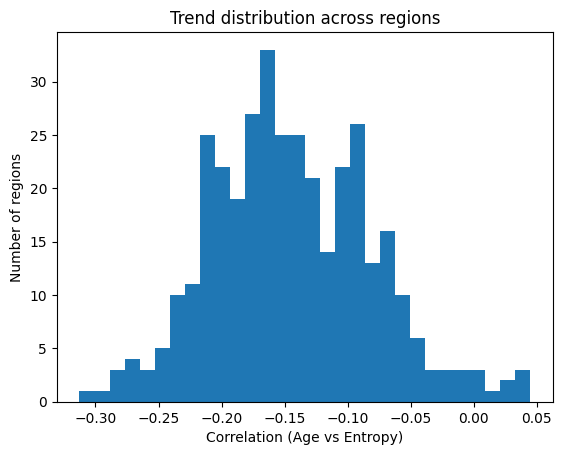

In [ ]:
corrs = [x[1] for x in results]

import matplotlib.pyplot as plt

plt.hist(corrs, bins=30)
plt.xlabel("Correlation (Age vs Entropy)")
plt.ylabel("Number of regions")
plt.title("Trend distribution across regions")
plt.show()

In [ ]:
top_regions = results[:10]

for r, corr, p in top_regions:
    print(f"Region {region_dict[r]}: corr={corr:.3f}, p={p:.4f}")

Region R_Primary_Visual_Cortex: corr=-0.313, p=0.0000
Region R_Second_Visual_Area: corr=-0.290, p=0.0000
Region R_Area_V3A: corr=-0.285, p=0.0000
Region R_Area_PF_Complex: corr=-0.284, p=0.0000
Region R_Area_PFm_Complex: corr=-0.282, p=0.0000
Region L_Second_Visual_Area: corr=-0.273, p=0.0000
Region R_Third_Visual_Area: corr=-0.267, p=0.0000
Region L_Primary_Visual_Cortex: corr=-0.266, p=0.0000
Region R_Parieto-Occipital_Sulcus_Area_1: corr=-0.265, p=0.0000
Region L_Area_posterior_9-46v: corr=-0.260, p=0.0000


In [ ]:
positive = [r for r, c, p in results if c > 0.2]
negative = [r for r, c, p in results if c < -0.2]
neutral  = [r for r, c, p in results if abs(c) <= 0.2]

print("Positive:", len(positive))
print("Negative:", len(negative))
print("Neutral:", len(neutral))

Positive: 0
Negative: 69
Neutral: 291
